# P1 signal audit

In [50]:
# Check the if the dataset is available
from pathlib import Path
import numpy as np
from PIL import Image

RESOURCE_DIR_KIRMIZI = Path("dataset/Pistachio_Image_Dataset/Pistachio_Image_Dataset/Kirmizi_Pistachio")
RESOURCE_DIR_SIIRT    = Path("dataset/Pistachio_Image_Dataset/Pistachio_Image_Dataset/Siirt_Pistachio")

for name, folder in [("Kirmizi", RESOURCE_DIR_KIRMIZI), ("Siirt", RESOURCE_DIR_SIIRT)]:
    if folder.is_dir():
        print(f"OK   {name}: {folder.resolve()}")
    else:
        print(f"MISS {name}: {folder.resolve()}")



# Cap how many images to load per class
LIMIT = 5 # None = load everyting

records = []
for name, folder in [("Kirmizi", RESOURCE_DIR_KIRMIZI), ("Siirt", RESOURCE_DIR_SIIRT)]:
    count = 0
    for path in sorted(folder.rglob("*")):
        if path.suffix.lower() not in {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}:
            continue
        if LIMIT is not None and count >= LIMIT:
            break
        with Image.open(path) as im:
            arr = np.asarray(im.convert("RGB"))
        records.append({"class": name, "path": path, "arr": arr})
        count += 1

print(f"Loaded {len(records)} images (LIMIT={LIMIT} per class)")

OK   Kirmizi: /home/vibe/skole/IDIG4120/p0/dataset/Pistachio_Image_Dataset/Pistachio_Image_Dataset/Kirmizi_Pistachio
OK   Siirt: /home/vibe/skole/IDIG4120/p0/dataset/Pistachio_Image_Dataset/Pistachio_Image_Dataset/Siirt_Pistachio
Loaded 10 images (LIMIT=5 per class)


# Format, array shape, data type, units, range and byte size

In [51]:
# 1. Format (from magic bytes, not the extension)
def detect_format(path):
    with open(path, "rb") as fh:
        head = fh.read(8)
    if head.startswith(b"\xff\xd8\xff"):
        return "JPEG"
    if head.startswith(b"\x89PNG"):
        return "PNG"
    return "other"

formats = {r["class"]: {} for r in records}
for r in records:
    fmt = detect_format(r["path"])
    formats[r["class"]][fmt] = formats[r["class"]].get(fmt, 0) + 1
print("1. Format:", formats)

# 2. Array shape
shapes = {r["arr"].shape for r in records}
print("2. Per-image (H, W, C):", shapes)

# 3. Data type
print("3. Data type:", records[0]["arr"].dtype)

# 4. Units
stacked = np.stack([r["arr"] for r in records])
lo, hi = int(stacked.min()), int(stacked.max())
is_8bit = lo >= 0 and hi <= 255
print(f"4. Units: pixel values are 8-bit intensity levels 0-255")
print(f"   Verified: observed range {lo}-{hi} -> within 0-255: {is_8bit}")

# 5. Range (per channel, across the loaded subset)
stacked = np.stack([r["arr"] for r in records])
for i, ch in enumerate("RGB"):
    print(f"5. {ch}: min={stacked[..., i].min()} max={stacked[..., i].max()}")

# 6. Byte size (per image)
for r in records[:1]:
    disk = r["path"].stat().st_size
    mem = r["arr"].nbytes
    print(f"6. {r['class']:8s} {r['path'].name:20s} on disk: {disk:>8} B | in memory: {mem:>8} B")

1. Format: {'Kirmizi': {'JPEG': 5}, 'Siirt': {'JPEG': 5}}
2. Per-image (H, W, C): {(600, 600, 3)}
3. Data type: uint8
4. Units: pixel values are 8-bit intensity levels 0-255
   Verified: observed range 0-255 -> within 0-255: True
5. R: min=0 max=255
5. G: min=0 max=255
5. B: min=0 max=255
6. Kirmizi  kirmizi (1).jpg      on disk:    22307 B | in memory:  1080000 B


# Sampling rate or spacing

In [60]:
img = records[0]["arr"]         
signal = img.flatten()           
print(f"Image shape: {img.shape}")
print(f"Flattened 1D signal length: {len(signal)} samples")

print(f"- Sampling: 1 sample per pixel along the raster scan.")
print(f"- Spatial sampling grid: {img.shape[1]} x {img.shape[0]} px.")

with Image.open(records[0]["path"]) as im:
    dpi = im.info.get("dpi")

if dpi:
    px_per_mm = dpi[0] / 25.4
    print(f"- DPI metadata present: {dpi[0]:.0f} x {dpi[1]:.0f} "
          f"= {px_per_mm:.2f} px/mm.")
else:
    print("- DPI metadata: NOT AVAILABLE / UNKNOWN (not stored in the file).")

Image shape: (600, 600, 3)
Flattened 1D signal length: 1080000 samples
- Sampling: 1 sample per pixel along the raster scan.
- Spatial sampling grid: 600 x 600 px.
- DPI metadata present: 96 x 96 = 3.78 px/mm.


Note:
This is not the physical sampling rate. This cannot be found, as a physical size of an pixel cannot be determined.

We can state the sampling density as 1 sample per pixel on 600x600.
Where we use the dot per inch to calulate how many pixels per inch, as placeholder for sampling rate. As we cannot state this physical terms like sample per mm or inch. Because the dataset provides no real calibration.

# Spatial view and one frequency view, both with labelled axes.

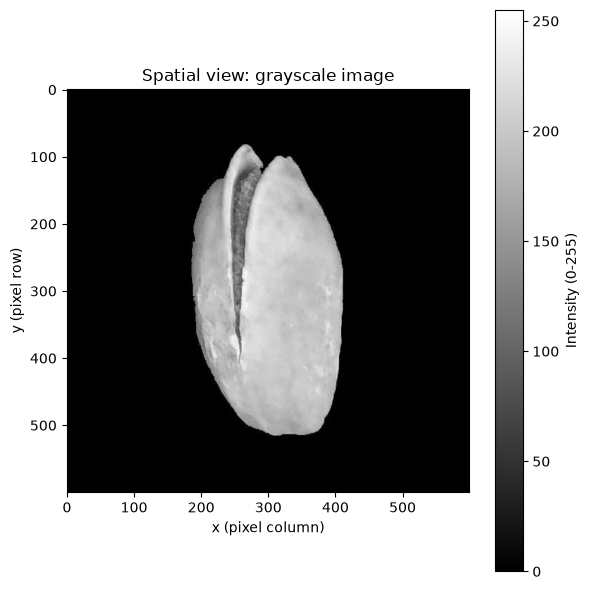

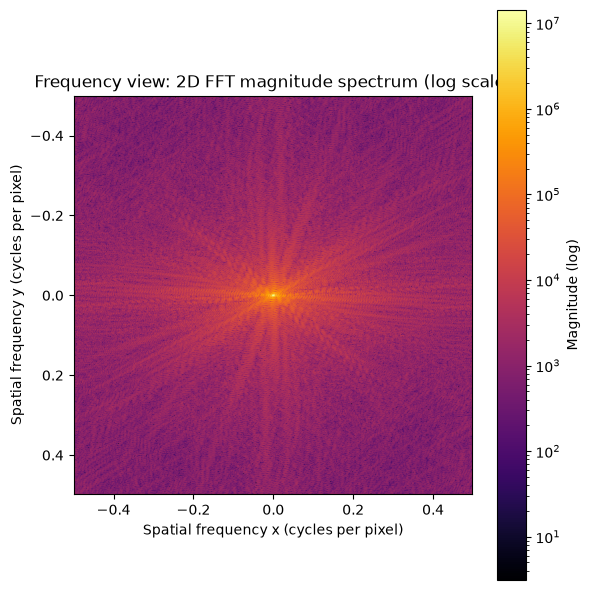

In [62]:
import numpy as np
import matplotlib.pyplot as plt

# grey scale conversion
gray = np.mean(records[0]["arr"], axis=2)   # extract the (H, W)
H, W = gray.shape

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(gray, cmap="gray", vmin=0, vmax=255)
ax.set_xlabel("x (pixel column)")
ax.set_ylabel("y (pixel row)")
ax.set_title("Spatial view: grayscale image")
plt.colorbar(im, ax=ax, label="Intensity (0-255)")
plt.tight_layout()
plt.show()

spectrum = np.abs(np.fft.fftshift(np.fft.fft2(gray)))
freq_x = np.fft.fftshift(np.fft.fftfreq(W, d=1.0))   # cycles/pixel, x
freq_y = np.fft.fftshift(np.fft.fftfreq(H, d=1.0))   # cycles/pixel, y

fig2, ax2 = plt.subplots(figsize=(6, 6))
im2 = ax2.imshow(spectrum, extent=[freq_x[0], freq_x[-1], freq_y[-1], freq_y[0]],
                 cmap="inferno", norm="log")
ax2.set_xlabel("Spatial frequency x (cycles per pixel)")
ax2.set_ylabel("Spatial frequency y (cycles per pixel)")
ax2.set_title("Frequency view: 2D FFT magnitude spectrum (log scale)")
plt.colorbar(im2, ax=ax2, label="Magnitude (log)")
plt.tight_layout()
plt.show()


We turn a spatial domain, the pixels, into a frequency domain. here we can see the variation in frequncies for sharp edges and detail.

# One transform or filtering experiment, with the prediction you made before running it.

prediction:
We run a gaussian filter, that redueces high spatial frequencies, but overall shape and large color will be kept. 

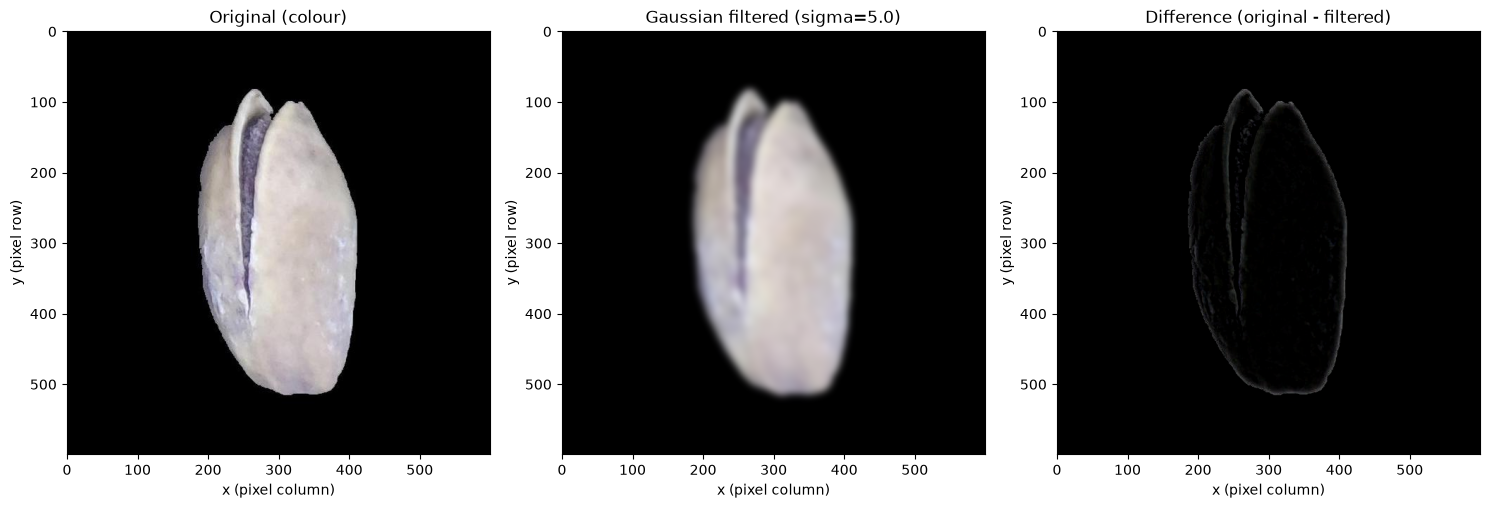

sigma=5.0: high spatial frequencies attenuated; overall shape and large-scale structure preserved (matches prediction).


In [63]:
import numpy as np
import matplotlib.pyplot as plt


img = records[0]["arr"].astype(float)

def gaussian_kernel(sigma, size=None):
    if size is None:
        size = int(6 * sigma) | 1  
    x = np.arange(size) - size // 2
    k = np.exp(-(x ** 2) / (2 * sigma ** 2))
    return k / k.sum()

def convolve1d(signal, kernel):
    return np.convolve(signal, kernel, mode="same")

def gaussian_filter2d(arr, sigma):
    k = gaussian_kernel(sigma)
    out = np.apply_along_axis(lambda r: convolve1d(r, k), axis=1, arr=arr)
    out = np.apply_along_axis(lambda c: convolve1d(c, k), axis=0, arr=out)
    return out

sigma = 5.0
blurred = np.stack([gaussian_filter2d(img[..., c], sigma) for c in range(3)], axis=2)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img.astype(np.uint8))
axes[0].set_title("Original (colour)")
axes[0].set_xlabel("x (pixel column)")
axes[0].set_ylabel("y (pixel row)")

axes[1].imshow(np.clip(blurred, 0, 255).astype(np.uint8))
axes[1].set_title(f"Gaussian filtered (sigma={sigma})")
axes[1].set_xlabel("x (pixel column)")
axes[1].set_ylabel("y (pixel row)")

diff = img - blurred
imd = axes[2].imshow(np.clip(diff, 0, 255).astype(np.uint8))
axes[2].set_title("Difference (original - filtered)")
axes[2].set_xlabel("x (pixel column)")
axes[2].set_ylabel("y (pixel row)")
plt.tight_layout()
plt.show()

print(f"sigma={sigma}: high spatial frequencies attenuated; "
      f"overall shape and large-scale structure preserved (matches prediction).")

# Small test for the frequency view after running gaussian blur

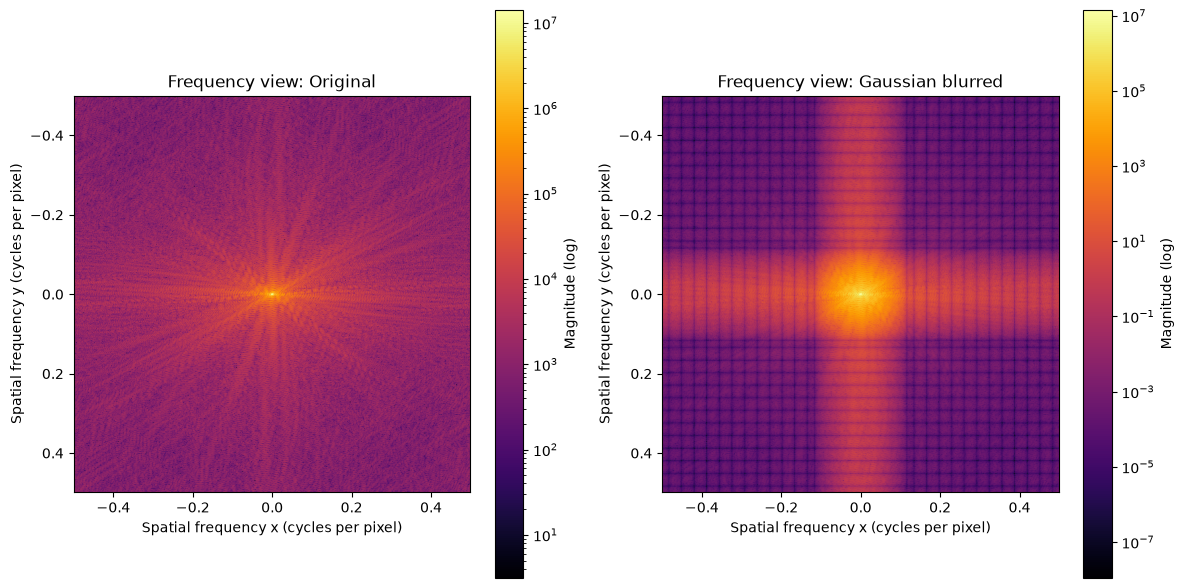

Blur attenuates high spatial frequencies: the blurred spectrum has less energy away from the centre (DC) than the original.


In [ ]:
gray_orig = np.mean(records[0]["arr"], axis=2) 
gray_blur = np.mean(blurred, axis=2)             
H, W = gray_orig.shape

# 2D FFT magnitude spectra (DC shifted to centre).
spec_orig = np.abs(np.fft.fftshift(np.fft.fft2(gray_orig)))
spec_blur = np.abs(np.fft.fftshift(np.fft.fft2(gray_blur)))

freq_x = np.fft.fftshift(np.fft.fftfreq(W, d=1.0))   # cycles/pixel, x
freq_y = np.fft.fftshift(np.fft.fftfreq(H, d=1.0))   # cycles/pixel, y

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, spec, title in [(axes[0], spec_orig, "Original"),
                        (axes[1], spec_blur, "Gaussian blurred")]:
    im = ax.imshow(spec, extent=[freq_x[0], freq_x[-1], freq_y[-1], freq_y[0]],
                   cmap="inferno", norm="log")
    ax.set_xlabel("Spatial frequency x (cycles per pixel)")
    ax.set_ylabel("Spatial frequency y (cycles per pixel)")
    ax.set_title(f"Frequency view: {title}")
    plt.colorbar(im, ax=ax, label="Magnitude (log)")
plt.tight_layout()
plt.show()

print("Blur attenuates high spatial frequencies: the blurred spectrum has "
      "less energy away from the centre (DC) than the original.")

So one interesting observation is running a frequency view over the blured image.

Here we can see the brightspot in the center still which is alot brighter. This represent lower frequnces.

the further from enter higher frequnices are. The gaussian blur is a lowpass filter so it suppresses some of the higher frequencies. So after bluring we see some of the specturm be somewhat stronger towards the center.

# One resampling experiment that finds an artefact or a limitation.

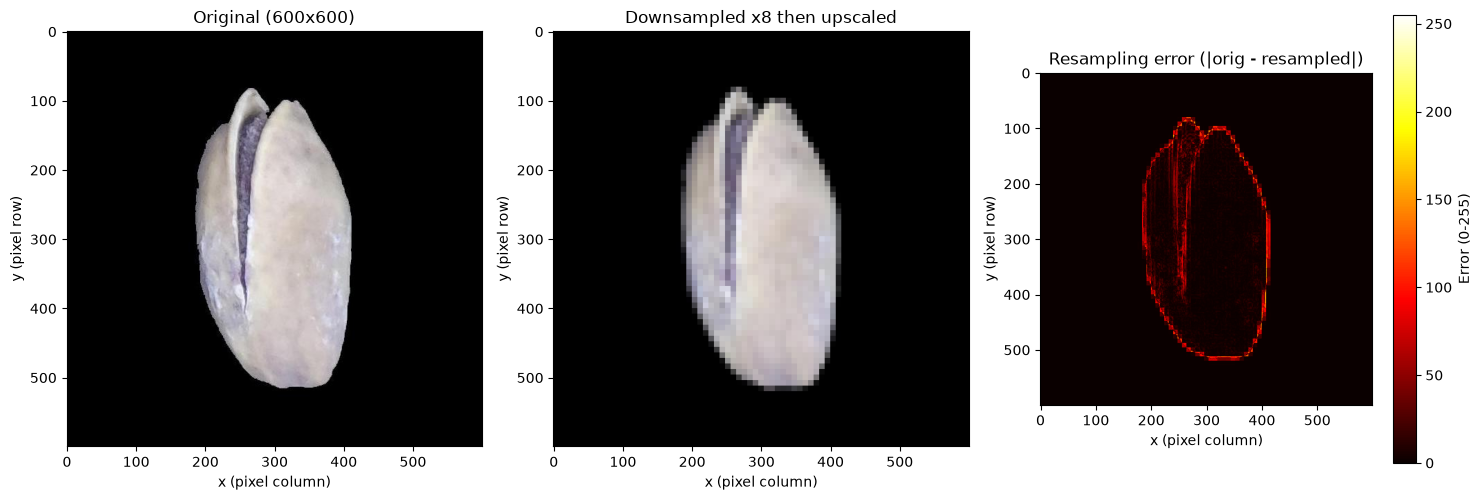

Downsampled from 600x600 to 75x75 px (factor 8).
Max resampling error: 190.7 / 255
Mean resampling error: 2.51 / 255
Artefact: loss of high-frequency detail (blurring/jagged edges). Limitation: fewer samples cannot represent fine spatial detail.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

img = records[0]["arr"].astype(float) 
H, W = img.shape[:2]

def downsample(arr, factor):
    h, w = arr.shape[0] // factor * factor, arr.shape[1] // factor * factor
    a = arr[:h, :w]
    return a.reshape(h // factor, factor, w // factor, factor, 3).mean(axis=(1, 3))

factor = 8
small = downsample(img, factor)
upscaled = np.repeat(np.repeat(small, factor, axis=0), factor, axis=1)

# --- Visual validation of the artefact ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img.astype(np.uint8))
axes[0].set_title(f"Original ({W}x{H})")
axes[0].set_xlabel("x (pixel column)")
axes[0].set_ylabel("y (pixel row)")

axes[1].imshow(np.clip(upscaled, 0, 255).astype(np.uint8))
axes[1].set_title(f"Downsampled x{factor} then upscaled")
axes[1].set_xlabel("x (pixel column)")
axes[1].set_ylabel("y (pixel row)")

diff = np.abs(img - upscaled)
imd = axes[2].imshow(diff.max(axis=2), cmap="hot", vmin=0, vmax=255)
axes[2].set_title("Resampling error (|orig - resampled|)")
axes[2].set_xlabel("x (pixel column)")
axes[2].set_ylabel("y (pixel row)")
plt.colorbar(imd, ax=axes[2], label="Error (0-255)")
plt.tight_layout()
plt.show()

max_err = diff.max()
mean_err = diff.mean()
print(f"Downsampled from {W}x{H} to {W//factor}x{H//factor} px (factor {factor}).")
print(f"Max resampling error: {max_err:.1f} / 255")
print(f"Mean resampling error: {mean_err:.2f} / 255")
print("Artefact: loss of high-frequency detail (blurring/jagged edges). "
      "Limitation: fewer samples cannot represent fine spatial detail.")

# A reproducible loader, and the baseline representation P2 will be measured against

In [ ]:
import numpy as np
from pathlib import Path
from PIL import Image

def load_images(folder: Path, limit=None):
    records = []
    for path in sorted(folder.rglob("*")):
        if path.suffix.lower() not in {".jpg", ".jpeg"}: # all images are jpg
            continue
        if limit is not None and len(records) >= limit:
            break
        with Image.open(path) as im:
            arr = np.asarray(im.convert("RGB"))   # (H, W, color channels (3)) uint8
        records.append({"path": path, "arr": arr})
    return records

baseline = []
for folder in (RESOURCE_DIR_KIRMIZI, RESOURCE_DIR_SIIRT):
    baseline.extend(load_images(folder, limit=LIMIT))

X = np.stack([r["arr"] for r in baseline])
print(f"Baseline representation shape: {X.shape}")
print(f"Data type: {X.dtype}")
print(f"Total bytes (raw RGB): {X.nbytes}")
print(f"Per-image bytes: {X[0].nbytes}")
print("This raw uint8 RGB array is the reference P2 codecs are compared against "
      "(lossless baseline; any codec's output is measured against this).")

Baseline representation shape: (10, 600, 600, 3)
Data type: uint8
Total bytes (raw RGB): 10800000
Per-image bytes: 1080000
This raw uint8 RGB array is the reference P2 codecs are compared against (lossless baseline; any codec's output is measured against this).


# Visual informatics concern
- The physical sampling rate is unknown. This will be based on the spatial sampling, where 1 sample is 1 pixel. And the dpi decies what the sampling rate is. 
 

# Implementation integrity and security concern.
- The image loader trust the file extension and metadata without verification
- The pictues has been preprocced and is undocumented. 